# Task 5 - Canny Edge Detection

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("smarties.png")

if bgr is None:
    raise FileNotFoundError(
        "Place smarties.png in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


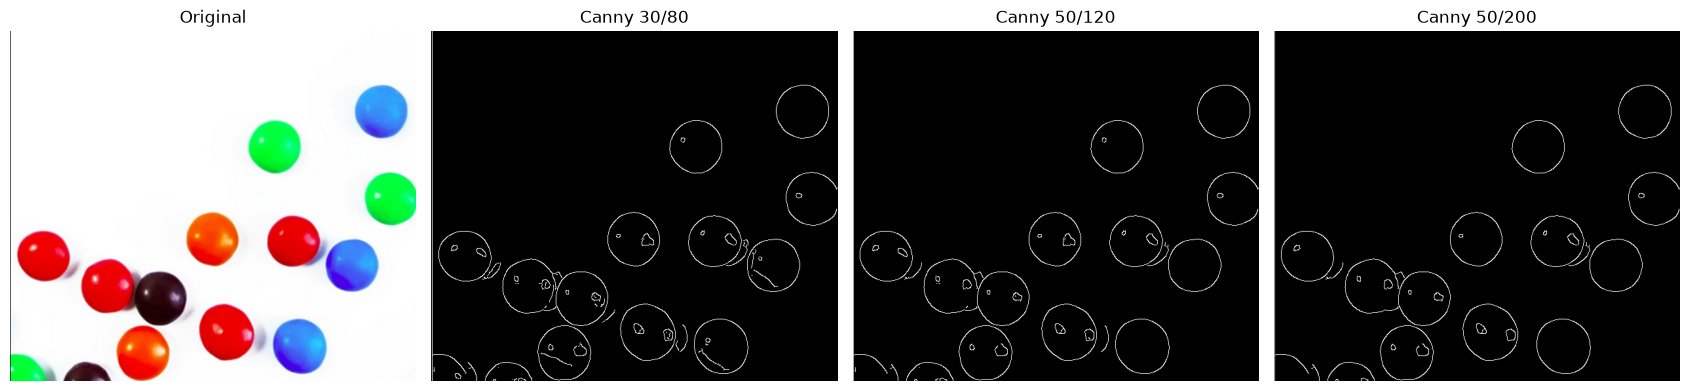

True

In [3]:
# Convert the image to grayscale
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise before edge detection
blur = cv2.GaussianBlur(gray, (5, 5), 1)

# Define different Canny threshold pairs
pairs = [
    (30, 80),
    (50, 120),
    (50, 200)
]

# Apply Canny edge detection using each threshold pair
edges = [
    cv2.Canny(blur, low, high)
    for low, high in pairs
]


# ---------------------------------------------------------
# Display the original image and Canny edge results
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 4, figsize=(17, 4))

# Display the original image
ax[0].imshow(rgb)
ax[0].set_title("Original")
ax[0].axis("off")

# Display each Canny edge result
for a, (thresholds, edge) in zip(
    ax[1:],
    zip(pairs, edges)
):
    a.imshow(edge, cmap="gray")
    a.set_title(f"Canny {thresholds[0]}/{thresholds[1]}")
    a.axis("off")

# Adjust spacing and display the results
plt.tight_layout()
plt.show()


# Save the second Canny result (50/120)
cv2.imwrite(
    str(OUT / "task5_final.png"),
    edges[1]
)


## Analysis
Low/high thresholds control hysteresis. Pixels above the high threshold are strong edges; pixels between low and high survive only when connected to strong edges. Low thresholds retain more weak boundaries but can introduce unwanted edges. Raising the high threshold makes strong-edge acceptance stricter and can cause faint boundaries to disappear. The middle pair `50/120` is used as the balanced final result.